In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import functions.mdata_utils as mdata_utils


## load mdata

In [46]:
mdata = mu.read(r"E:\Biology\scRNA\Tumor\human\gex+tcr\GSE139555 Pan-cancer\GSE139555_mdata.h5mu")

# Rename modalities: 'rna' -> 'gex' and 'tcr' -> 'airr'
if 'rna' in mdata.mod.keys():
    mdata.mod['gex'] = mdata.mod.pop('rna')
if 'tcr' in mdata.mod.keys():
    mdata.mod['airr'] = mdata.mod.pop('tcr')
mdata.update()

mdata_ori = mdata.copy()
mdata

MuData object with n_obs × n_vars = 200626 × 30727
  obs:	'rna:GSM', 'rna:tissue', 'tcr:c_gene', 'tcr:cdr3', 'tcr:cdr3_nt', 'tcr:chain', 'tcr:d_gene', 'tcr:j_gene', 'tcr:productive', 'tcr:v_gene', 'GSM', 'tissue', 'ident', 'patient', 'sample', 'source', 'clonotype'
  obsm:	'rna', 'tcr'
  varm:	'rna', 'tcr'
  2 modalities
    gex:	200626 x 30727
      obs:	'GSM', 'tissue'
    airr:	200626 x 0
      obs:	'c_gene', 'cdr3', 'cdr3_nt', 'chain', 'd_gene', 'j_gene', 'productive', 'v_gene'

In [47]:

# Human TCR gene prefixes (uppercase)
prefixes_to_remove = ('CMO', 'ENSM',
                      'TRAV', 'TRAJ', 'TRAC', 'TRBV', 'TRBJ', 
                     'TRBC', 'TRDV', 'TRDJ', 'TRDC', 'TRGV', 'TRGJ', 'TRGC') 

TCR_gene_mask = mdata.var_names.str.startswith(prefixes_to_remove)
mdata = mdata[:, ~TCR_gene_mask]

mdata['gex'].var_names_make_unique()

sc.pp.normalize_total(mdata['gex'])
sc.pp.log1p(mdata['gex'])


In [ ]:
# airr
# ir.pp.index_chains(mdata)
# ir.tl.chain_qc(mdata)

# # by nucleotide acid seq
# ir.pp.ir_dist(mdata)
# ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")
# # ir.tl.clonotype_network(mdata, min_cells=10)

# meta_airr = ir.get.airr(mdata['airr'], ["cdr3_aa", "v_call", "j_call"] ,  ('VJ_1', 'VDJ_1'))
# mdata.obs = mdata.obs.join(meta_airr)
# mdata.update()

# # mdata.obs = mdata.obs.reindex(mdata.mod['gex'].obs.index)
mdata

View of MuData object with n_obs × n_vars = 200626 × 30727
  obs:	'rna:GSM', 'rna:tissue', 'tcr:c_gene', 'tcr:cdr3', 'tcr:cdr3_nt', 'tcr:chain', 'tcr:d_gene', 'tcr:j_gene', 'tcr:productive', 'tcr:v_gene', 'GSM', 'tissue', 'ident', 'patient', 'sample', 'source', 'clonotype'
  obsm:	'rna', 'tcr'
  varm:	'rna', 'tcr'
  2 modalities
    gex:	200626 x 30727
      obs:	'GSM', 'tissue'
      uns:	'log1p'
    airr:	200626 x 0
      obs:	'c_gene', 'cdr3', 'cdr3_nt', 'chain', 'd_gene', 'j_gene', 'productive', 'v_gene'

## QC

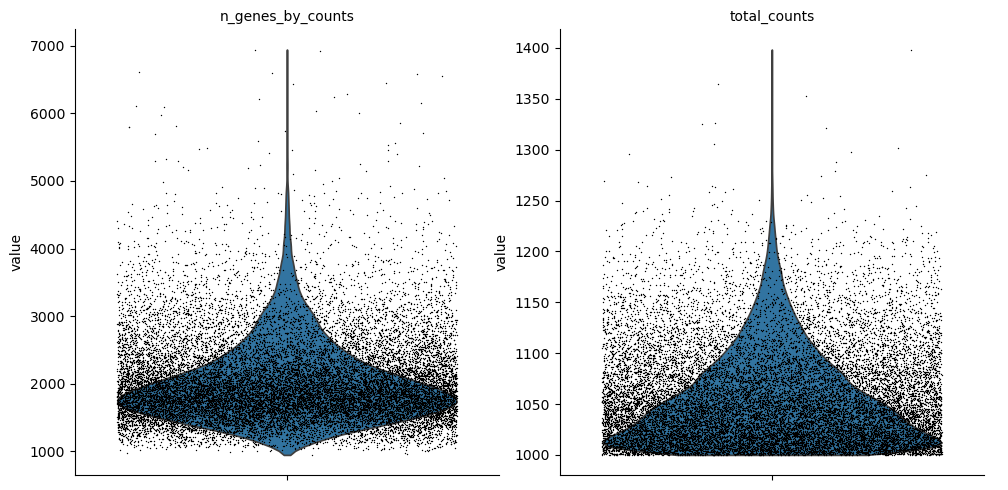

In [ ]:
# Human mitochondrial genes (uppercase)
mdata['gex'].var["mt"] = mdata['gex'].var_names.str.startswith("MT-")
# ribosomal genes (human uses RPS/RPL)
mdata['gex'].var["ribo"] = mdata['gex'].var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes (human uses HB)
mdata['gex'].var["hb"] = mdata['gex'].var_names.str.contains("^HB[^(P)]", regex=True)

sc.pp.calculate_qc_metrics(
    mdata['gex'], qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)
# 
sc.pp.filter_cells(mdata['gex'], min_genes= 300)
sc.pp.filter_cells(mdata['gex'], max_genes= 7000)

sc.pp.filter_cells(mdata['gex'], min_counts=1000)
sc.pp.filter_cells(mdata['gex'], max_counts=40000)

sc.pp.filter_genes(mdata['gex'], min_cells=50)

sc.pl.violin(
    mdata['gex'],
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

In [ ]:
# Check if batch key exists (common human keys: 'sample_id', 'patient_id', 'batch')
batch_key = None
for key in ['sample_id', 'patient_id', 'batch', 'donor_id']:
    if key in mdata['gex'].obs.columns:
        batch_key = key
        break

if batch_key:
    sc.pp.highly_variable_genes(mdata['gex'], n_top_genes=2500, batch_key=batch_key)
else:
    sc.pp.highly_variable_genes(mdata['gex'], n_top_genes=2500)
    
mdata.mod['gex'] = mdata['gex'][:, mdata['gex'].var['highly_variable']].copy()


In [63]:

# List of genes to add back from mdata_ori (if filtered out)
genes_to_add_back = ['PTPRC', 'CD3D', 'CD3E', 'CD3G']

# Add genes back from mdata_ori if they're not in the filtered genes
genes_added = []
for gene in genes_to_add_back:
    if gene in mdata_ori['gex'].var_names and gene not in mdata['gex'].var_names:
        # Subset mdata_ori to match current cells (after filtering)
        gene_subset = mdata_ori['gex'][mdata['gex'].obs.index, gene]
        
        # Concatenate gene to the filtered mdata
        import anndata as ad
        mdata.mod['gex'] = ad.concat([mdata['gex'], gene_subset], axis=1, merge='same')
        genes_added.append(gene)
        print(f"Added {gene} back to mdata['gex']")
    elif gene in mdata['gex'].var_names:
        print(f"{gene} already present in mdata['gex']")
    else:
        print(f"{gene} not found in mdata_ori['gex']")

if genes_added:
    print(f"\nSuccessfully added {len(genes_added)} gene(s): {genes_added}")

Added PTPRC back to mdata['gex']
CD3D already present in mdata['gex']
Added CD3E back to mdata['gex']
Added CD3G back to mdata['gex']

Successfully added 3 gene(s): ['PTPRC', 'CD3E', 'CD3G']


In [65]:
mdata = mdata_utils.sync_mdata_obs(mdata)
mdata

MuData object with n_obs × n_vars = 20899 × 2503
  obs:	'rna:GSM', 'rna:tissue', 'tcr:c_gene', 'tcr:cdr3', 'tcr:cdr3_nt', 'tcr:chain', 'tcr:d_gene', 'tcr:j_gene', 'tcr:productive', 'tcr:v_gene', 'GSM', 'tissue', 'ident', 'patient', 'sample', 'source', 'clonotype'
  2 modalities
    gex:	20899 x 2503
      obs:	'GSM', 'tissue'
    airr:	20899 x 0
      obs:	'c_gene', 'cdr3', 'cdr3_nt', 'chain', 'd_gene', 'j_gene', 'productive', 'v_gene'

## Annotation

In [66]:
sc.pp.pca(mdata["gex"], svd_solver="arpack", n_comps=50)
sc.pp.neighbors(mdata["gex"], n_neighbors = 50)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)


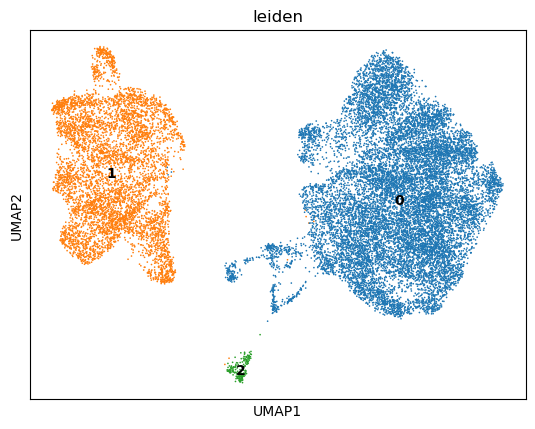

In [67]:
sc.tl.leiden(mdata["gex"], resolution = 0.1, n_iterations=-1, flavor = 'igraph')
sc.pl.umap(mdata["gex"], color="leiden", legend_loc="on data")

In [68]:
# Cell type annotation based on marker genes
# Define marker gene sets for different cell types (human gene symbols)
marker_dict = {
    'CD4+ T': ['CD4', 'IL7R', 'CCR7', 'TCF7'],
    'CD8+ T': ['CD8A', 'CD8B', 'GZMB', 'PRF1'],
    'Treg': ['FOXP3', 'IL2RA', 'CTLA4'],
    'NK': ['NCAM1', 'NKG7', 'GNLY', 'KLRD1'],
    'B': ['CD19', 'CD79A', 'MS4A1', 'CD79B'],
    'Myeloid': ['CD68', 'ITGAM', 'CD14', 'CD33'],
    'Monocyte': ['CD14', 'FCGR3A', 'LYZ'],
    'Macrophage': ['CD68', 'CD163', 'MRC1'],
    'DC': ['FCER1A', 'CLEC9A', 'IRF8'],
    'Plasma': ['IGHG1', 'IGHG2', 'JCHAIN', 'XBP1'],
    'T_Naive': ['CCR7', 'SELL', 'TCF7', 'LEF1'],
    'T_Effector': ['GZMB', 'PRF1', 'IFNG'],
    'T_Exhausted': ['PDCD1', 'TOX', 'LAG3', 'HAVCR2']
}

# Score each cell type based on marker expression
for cell_type, markers in marker_dict.items():
    # Filter markers that exist in the data
    available_markers = [m for m in markers if m in mdata['gex'].var_names]
    if len(available_markers) > 0:
        sc.tl.score_genes(mdata['gex'], gene_list=available_markers, score_name=f'{cell_type}_score')
    else:
        print(f"Warning: No markers found for {cell_type}")

# Annotate cell types based on highest score
cell_type_scores = [col for col in mdata['gex'].obs.columns if col.endswith('_score')]
if cell_type_scores:
    # Get the cell type with highest score for each cell
    score_matrix = mdata['gex'].obs[cell_type_scores].values
    max_idx = np.argmax(score_matrix, axis=1)
    cell_type_names = [col.replace('_score', '') for col in cell_type_scores]
    mdata['gex'].obs['cell_type'] = [cell_type_names[i] for i in max_idx]
    
    # Set low-confidence annotations (if max score is too low)
    max_scores = score_matrix.max(axis=1)
    low_confidence_threshold = np.percentile(max_scores, 10)  # Bottom 10% of scores
    mdata['gex'].obs.loc[max_scores < low_confidence_threshold, 'cell_type'] = 'Unknown'
    
    print("Cell type annotation complete!")
    print("\nCell type distribution:")
    print(mdata['gex'].obs['cell_type'].value_counts())
else:
    print("No cell type scores computed")

Cell type annotation complete!

Cell type distribution:
cell_type
NK             3667
Monocyte       3558
Plasma         2218
Treg           2152
Unknown        2090
CD8+ T         1569
T_Exhausted     984
CD4+ T          981
T_Effector      963
Macrophage      928
T_Naive         647
Myeloid         456
DC              375
B               311
Name: count, dtype: int64


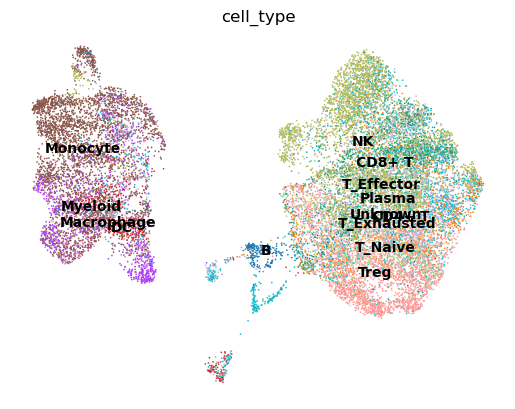

In [69]:
# Visualize cell type annotation
sc.pl.umap(mdata["gex"], color="cell_type", legend_loc="on data", frameon=False)

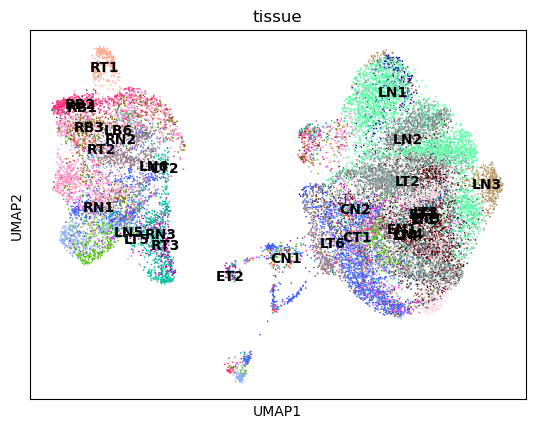

In [70]:
# Plot available metadata columns (common human metadata)
plot_cols = []
for col in ["tissue"]:
    if col in mdata["gex"].obs.columns:
        plot_cols.append(col)
        
if plot_cols:
    sc.pl.umap(mdata["gex"], color=plot_cols, legend_loc="on data")


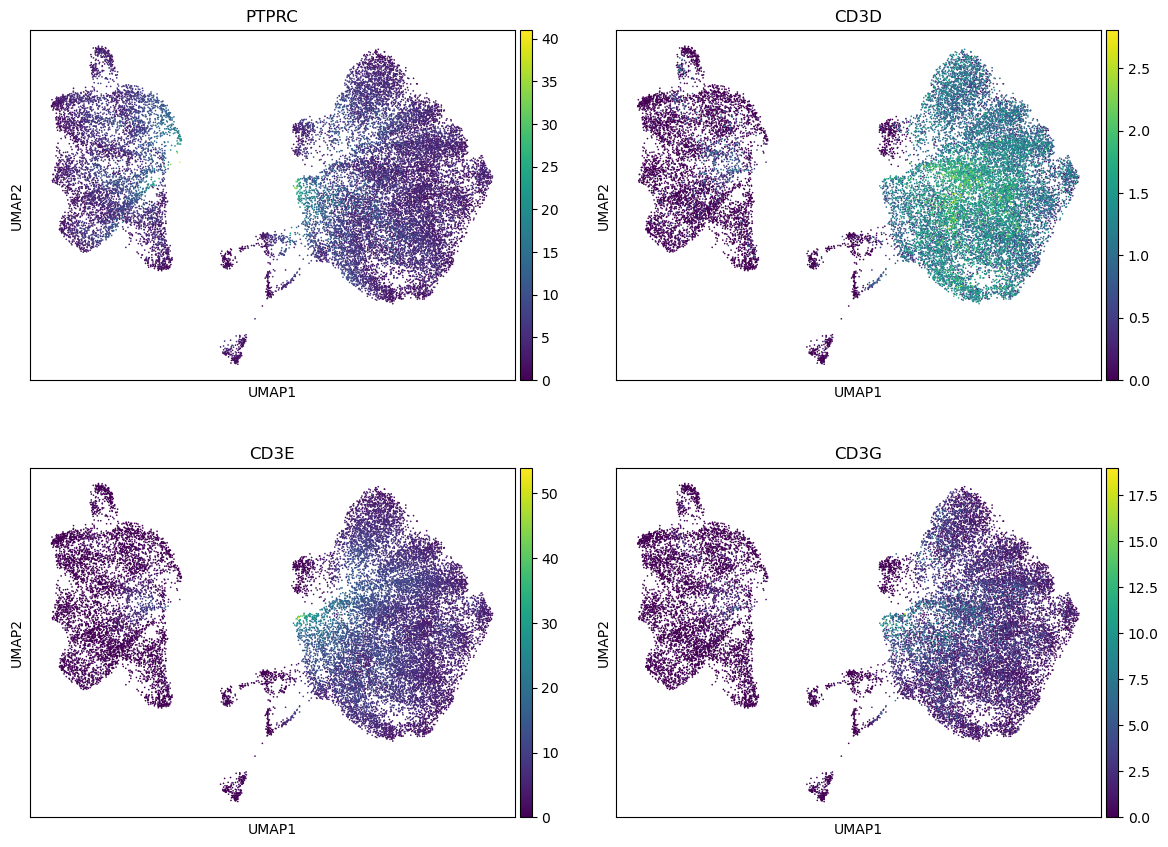

In [71]:
# Human T cell markers (uppercase gene symbols)
markers_in = []
sort_markers = ['PTPRC', 'CD3D', 'CD3E', 'CD3G']

CD4_markers = ['IL7R','CCR7','LTB','MAL','ICOS','CXCR4','TCF7','FOXP3','IL2RA']

for i in sort_markers:
    if i in mdata["gex"].var_names:
        markers_in.append(i) 
        
if markers_in:
    mu.pl.embedding(mdata["gex"], basis="umap", color= markers_in,  wspace = 0.1, ncols=2, vmin=0)
else:
    print("No type markers found in var_names. Available markers may use different naming.")

In [ ]:
CD8_Naive = ['TCF7', 'CCR7', 'LTB', 'IL7R']
CD8_Effector = ['GZMB', 'PRF1', 'IFNG']
CD8_TEM = ['GZMK', 'IFNG']
CD8_TRM = ['CD69', 'ITGAE', 'ZNF683']
CD8_TCM = ['CCR7', 'CD62L', 'IL7R', 'TCF7']
CD8_Exhausted = ['PDCD1', 'TOX', 'LAG3']

for i in CD8_Naive:
    if i in mdata["gex"].var_names:
        markers_in.append(i) 
        
if markers_in:
    mu.pl.embedding(mdata["gex"], basis="umap", color= markers_in,  wspace = 0.1, ncols=2, vmin=0)
else:
    print("No type markers found in var_names. Available markers may use different naming.")

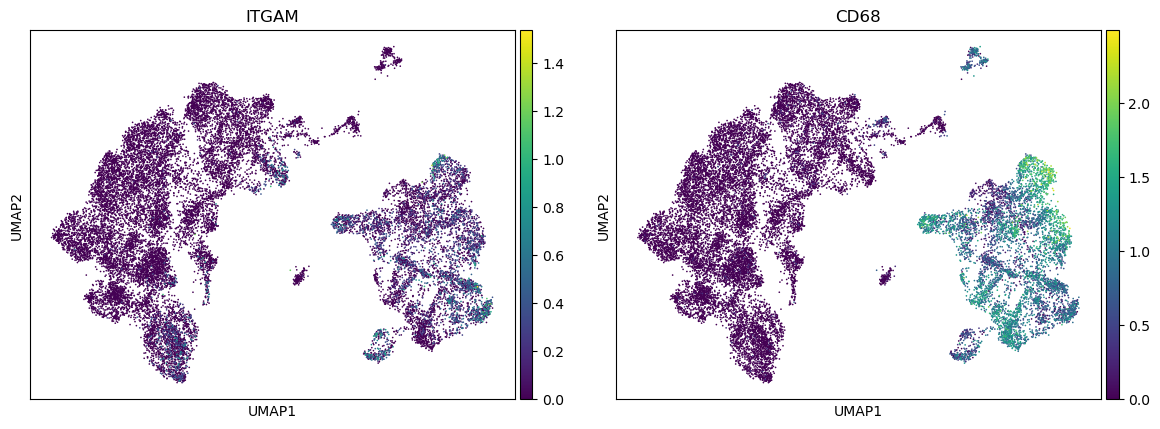

In [ ]:
# Human myeloid markers
myloid_markers = ['CD11B', 'ITGAM', 'CD33', 'CD45', 'PTPRC', 'CD68']
markers_in = []

for i in myloid_markers:
    if i in mdata["gex"].var_names:
        markers_in.append(i) 
        
if markers_in:
    mu.pl.embedding(mdata["gex"], basis="umap", color= markers_in,  wspace = 0.1, ncols=2, vmin=0)
else:
    print("No myeloid markers found in var_names.")

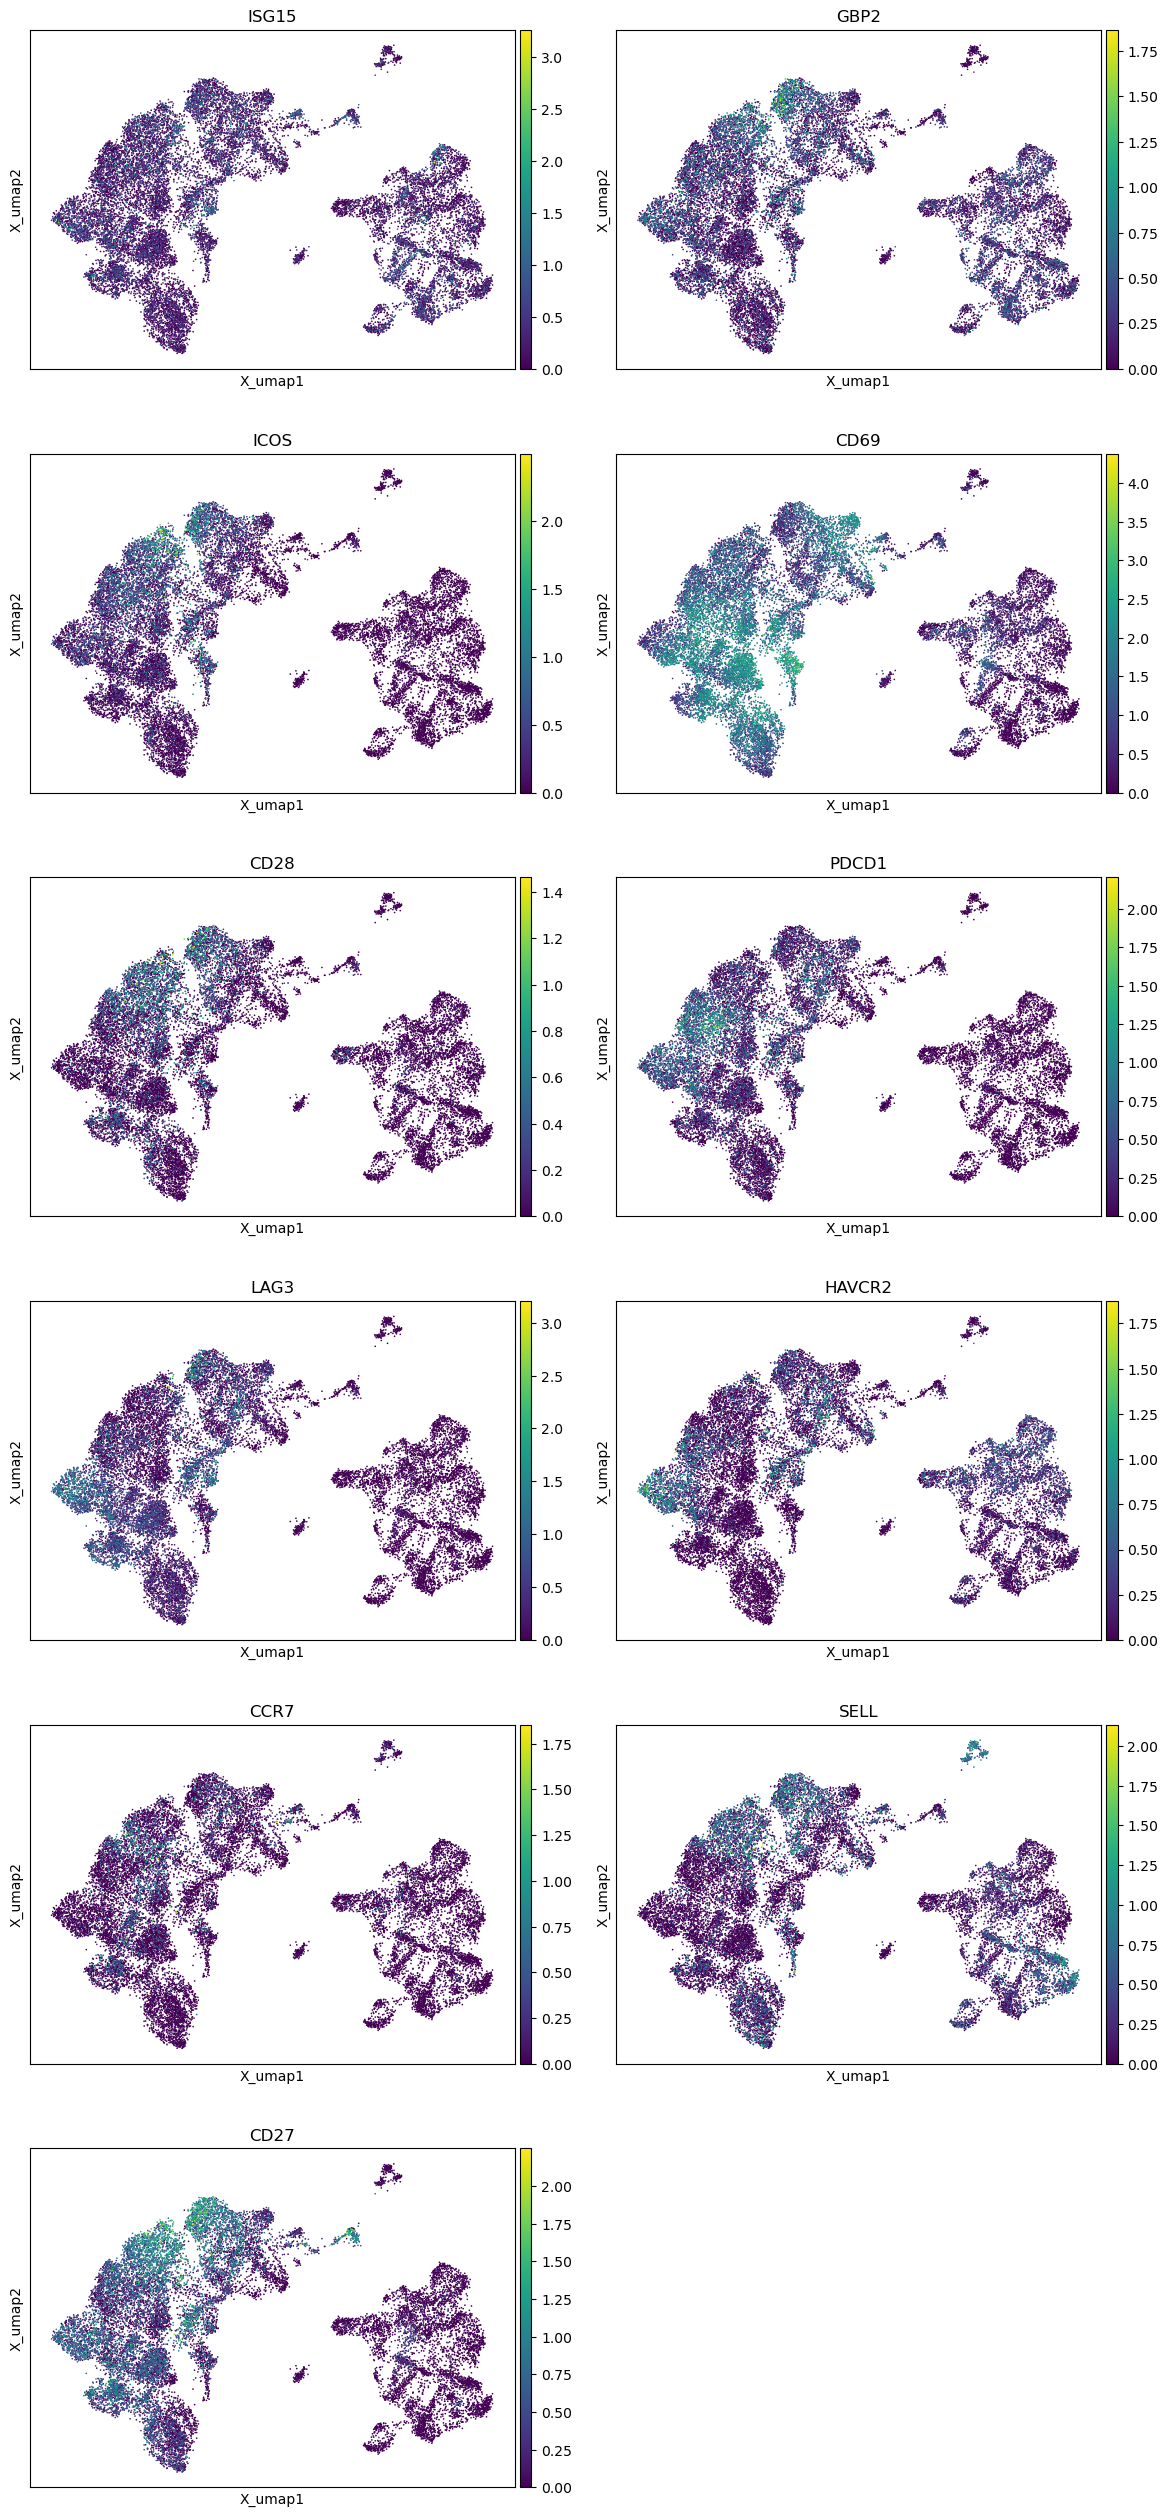

In [ ]:
state_markers = ['ISG15', 'GBP2', 'IFIH1', 'ICOS', 'CD69', 'CD28', 'PDCD1', 'LAG3', 'HAVCR2', 'CCR7', 'SELL', 'CD27']
markers_in = []
for i in state_markers:
    if i in mdata["gex"].var_names:
        markers_in.append(i) 
mu.pl.embedding(mdata, basis="gex:umap", color= markers_in, wspace = 0.1, ncols=2, vmin=0)

In [ ]:
import scanpy as sc

# Human gene symbols (uppercase)
IFN_stim = ['ISG15', 'GBP2', 'IFIH1']
Activation = ['ICOS', 'CD69', 'CD28']
Exhaust = ['PDCD1', 'LAG3', 'HAVCR2', 'TIGIT']
Mem = ['CCR7', 'SELL', 'CD27']

sc.tl.score_genes(mdata['gex'], gene_list=IFN_stim, score_name='IFN_stim')
sc.tl.score_genes(mdata['gex'], gene_list=Activation, score_name='Activation')
sc.tl.score_genes(mdata['gex'], gene_list=Exhaust, score_name='Exhaust')
sc.tl.score_genes(mdata['gex'], gene_list=Mem, score_name='Mem')

In [ ]:
# mdata['gex'].obs['state'] = 'Effector'
mdata['gex'].obs.loc[mdata['gex'].obs['Exhaust'] > 0.5, 'state'] = 'Exhausted'
mdata['gex'].obs.loc[mdata['gex'].obs['Mem'] > 0.5, 'state'] = 'Mem'
mdata['gex'].obs.loc[mdata['gex'].obs['IFN_stim'] > 0.5, 'state'] = 'activated'
mdata['gex'].obs.loc[mdata['gex'].obs['Activation'] > 0.5, 'state'] = 'activated'


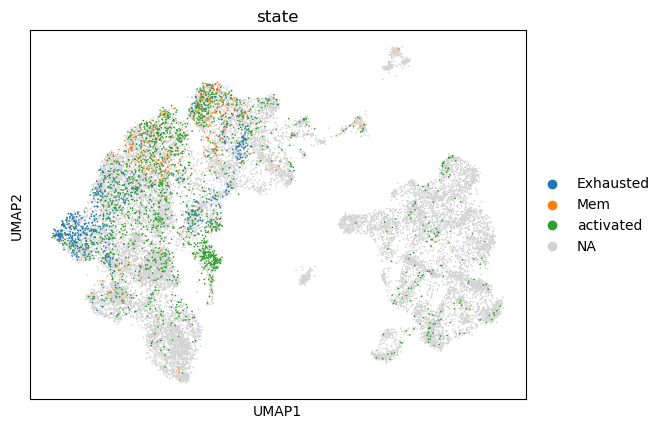

In [ ]:
sc.pl.umap(mdata["gex"], color=['state'])

## Pan-cancer analysis

### Subset analysis (modify based on your metadata)

In [ ]:
# Example: subset by available metadata (adjust based on your data structure)
# Check available columns for grouping
print("Available obs columns:", mdata['gex'].obs.columns.tolist()[:10])

# Example subset - modify based on your metadata
# If you have sample groups, patient groups, etc., use those instead
# subset_idx = (mdata['gex'].obs['sample_id'].astype('str').isin(['group1', 'group2']))
# mdata_subset1 = mdata[subset_idx.astype('bool')]
# mdata_subset2 = mdata[~subset_idx.astype('bool')]

# For now, skip subsetting - modify this cell based on your analysis needs
# mdata['gex'].obs['is_subset'] = subset_idx

Available obs columns: ['GSM', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes']


In [ ]:
# Uncomment when you have defined a subset column
# sc.pl.umap(mdata["gex"], color=['is_subset'])
# For now, plot available metadata
if 'sample_id' in mdata["gex"].obs.columns:
    sc.pl.umap(mdata["gex"], color=['sample_id'])
elif 'patient_id' in mdata["gex"].obs.columns:
    sc.pl.umap(mdata["gex"], color=['patient_id'])

In [ ]:
### Single gene distribution (example - modify based on your analysis)
from scipy.stats import ranksums

# Example: Compare gene expression between groups
# Modify based on your specific comparison groups and genes of interest
# gene_name = 'CD4'  # or other gene of interest
# 
# for type_i in ['CD4+ T', 'CD8+ T', 'Treg']:
#     if type_i in mdata['gex'].obs['modified_cell_type'].values and gene_name in mdata['gex'].var_names:
#         expr_A = mdata_subset1['gex'][mdata_subset1['gex'].obs['modified_cell_type']== type_i][:, gene_name].X.toarray().flatten()
#         expr_B = mdata_subset2['gex'][mdata_subset2['gex'].obs['modified_cell_type']== type_i][:, gene_name].X.toarray().flatten()
#         if len(expr_A) > 0 and len(expr_B) > 0:
#             stat, pval = ranksums(expr_A, expr_B)
#             print(f"{type_i} - {gene_name} Wilcoxon rank-sum p-value:", pval)

print("Modify this cell based on your specific comparison needs")


Modify this cell based on your specific comparison needs


### Correlations of pseudobulk expression values

In [ ]:
import pandas as pd
from scipy.sparse import issparse
import numpy as np

def to_dense(X):
    if issparse(X):
        return X.toarray()
    return X

def clusters_corr(adata1, adata2):
    common = adata1.var_names.intersection(adata2.var_names)
    a1 = adata1[:, common]
    a2 = adata2[:, common]

    pb1 = to_dense(a1.X).mean(axis=0)
    pb2 = to_dense(a2.X).mean(axis=0)

    df = pd.DataFrame({"group1": pb1, "group2": pb2}, index=common)

    corr_pearson = df["group1"].corr(df["group2"], method="pearson")
    corr_spearman = df["group1"].corr(df["group2"], method="spearman")
    return corr_pearson, corr_spearman

# Correlations between samples/patients - modify based on available metadata
pearson = []
spearman = []

# Find grouping column (sample_id, patient_id, etc.)
group_col = None
for col in ['sample_id', 'patient_id', 'batch', 'donor_id']:
    if col in mdata['gex'].obs.columns:
        group_col = col
        break

if group_col:
    groups = mdata['gex'].obs[group_col].unique()
    for row_idx, cat1 in enumerate(groups):
        for col_idx, cat2 in enumerate(groups):
            if row_idx == col_idx:
                pearson.append(1)
                spearman.append(1)
            else:
                adata1 = mdata['gex'][mdata['gex'].obs[group_col]== cat1]
                adata2 = mdata['gex'][mdata['gex'].obs[group_col]== cat2]
                if len(adata1) > 0 and len(adata2) > 0:
                    stat, pval = clusters_corr(adata1, adata2)
                    pearson.append(pval)
                    spearman.append(stat)
                else:
                    pearson.append(0)
                    spearman.append(0)
    
    spearman_df = np.array(spearman).reshape([len(groups), len(groups)])
else:
    print(f"No suitable grouping column found. Available columns: {mdata['gex'].obs.columns.tolist()}")
    spearman_df = None

No suitable grouping column found. Available columns: ['GSM', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'leiden', 'modified_cell_type', 'IFN_stim', 'Activation', 'Exhaust', 'Mem', 'state']


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

if spearman_df is not None:
    group_col = None
    for col in ['sample_id', 'patient_id', 'batch', 'donor_id']:
        if col in mdata['gex'].obs.columns:
            group_col = col
            break
    
    if group_col:
        disp = ConfusionMatrixDisplay(confusion_matrix= np.tril(spearman_df), display_labels = mdata['gex'].obs[group_col].unique())
        disp.plot(cmap='Blues')
        plt.title('spearman corr')
        plt.show()
else:
    print("Cannot plot - spearman_df not computed")

Cannot plot - spearman_df not computed


## clonotype dist

In [ ]:
# Clone size analysis and cross-sample/tissue sharing

# Threshold on clone size
clone_thresh = 2
mdata.obs['cloned'] = mdata['airr'].obs['clone_id_size'] >= clone_thresh

# Check if clones appear across multiple samples/tissues/patients
# Modify based on available metadata column (tissue, sample_id, patient_id, etc.)
mdata_cloned = mdata[mdata.obs['cloned']]

# Find grouping column
group_col = None
for col in ['tissue', 'sample_id', 'patient_id']:
    if col in mdata_cloned['gex'].obs.columns:
        group_col = col
        break

if group_col:
    clone_group_df = mdata_cloned['airr'].obs[['clone_id']].join(mdata_cloned['gex'].obs[group_col])
    clone_group_counts = clone_group_df.groupby('clone_id')[group_col].nunique()
    multi_group_clones = clone_group_counts[clone_group_counts > 1].index
    mdata.obs['in_multiple_groups'] = mdata['airr'].obs['clone_id'].isin(multi_group_clones)
    print(f"Clones appearing in multiple {group_col}s:")
    print(mdata.obs['in_multiple_groups'].value_counts())
else:
    print(f"No suitable grouping column found for cross-group clone analysis. Available: {mdata_cloned['gex'].obs.columns.tolist()}")

KeyError: 'clone_id_size'

## TCR distance analysis

In [ ]:
def mdata_TCR_formating(mdata_subset):
    query_df = mdata_subset.obs[['VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call']].copy()
    query_df['cell_id'] = query_df.index
    query_df = query_df.dropna(subset = ["VDJ_1_cdr3_aa"])

    query_df.rename(columns={'VDJ_1_cdr3_aa': 'cdr3_b_aa', 'VDJ_1_v_call':'v_b_gene', 
                       'VDJ_1_j_call':'j_b_gene', }, inplace=True)

    query_df['cdr3_b_aa'] = query_df['cdr3_b_aa'].astype(str)
    
    query_df['v_b_gene'] = query_df['v_b_gene'].str.split('+').str[0]
    query_df['j_b_gene'] = query_df['j_b_gene'].str.split('+').str[0]

    query_df['v_b_gene'] = query_df['v_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')
    query_df['j_b_gene'] = query_df['j_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')

    query_df_unique = query_df.drop_duplicates(['cdr3_b_aa'])
    return query_df_unique


In [ ]:
def TCRdist_to_ref(ref_df, query_df_unique):
    # Change organism to 'human' for human data
    tr_ref = TCRrep(cell_df = ref_df, 
                organism = 'human', 
                chains = ['beta'],
                compute_distances = False,)

    tr_q = TCRrep(cell_df = query_df_unique, 
                organism = 'human', 
                chains = ['beta'],
                compute_distances = False,)

    tr_ref.compute_rect_distances(tr_ref.clone_df,  tr_q.clone_df)
    print(tr_ref.rw_beta.shape)
    print(tr_ref.rw_beta)
    return tr_ref, tr_q


(25, 50404)
[[ 99 122 106 ... 114 113 101]
 [138 131 112 ... 126 119 125]
 [117 128 118 ... 138 137 101]
 ...
 [102 110 106 ... 102 101 101]
 [102 122  94 ... 114 113  95]
 [111 116 118 ... 114 113  89]]
(25, 996)
[[121 109 107 ... 114 126 162]
 [118 121 128 ... 114 114 159]
 [118 121 113 ... 138 126 132]
 ...
 [121 109 107 ... 111 126 162]
 [121 109 107 ... 114 126 162]
 [118  97 101 ... 126 138 156]]


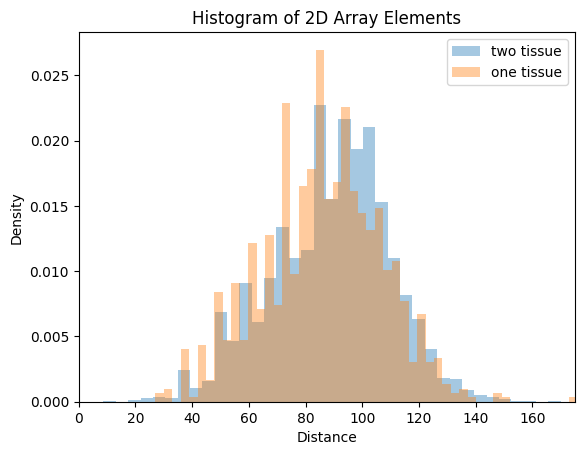

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from tcrdist.repertoire import TCRrep

# NOTE: This section requires a reference TCR repertoire (ref_df)
# If you have a human reference TCR dataset, load it here
# Otherwise, comment out or modify this section

# Example: Load reference if available
# ref_df = pd.read_csv('path/to/human_reference_TCRs.csv')
# ref_df.rename(columns={'cdr3_b_aa': 'cdr3_b_aa', 'v_b_gene':'v_b_gene', 
#                        'j_b_gene':'j_b_gene', }, inplace=True)
# ref_df['v_b_gene'] = ref_df['v_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')
# ref_df['j_b_gene'] = ref_df['j_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')

# For now, compute TCR distances within the dataset instead
# tr_list = []
# dist_thres = 85
# 
# # Use cloned cells or all cells based on your analysis
# mdata_sub = mdata[mdata.obs.get('cloned', pd.Series(False, index=mdata.obs.index))]
# 
# m_list = [mdata, mdata_sub]
# tcrDist_list = []
# 
# for mdata_sub in m_list:
#     query_df = mdata_TCR_formating(mdata_sub)
#     
#     if 'ref_df' in locals() and len(query_df) > 0:
#         tr_out, tr_query = TCRdist_to_ref(ref_df, query_df)
#         tr_list.append(tr_out)
#         
#         flat_arr = tr_out.rw_beta.min(axis=0).flatten()
#         TCR_all = tr_query.clone_df
#         TCR_all['TCRdist_ref'] = flat_arr
#         
#         tcrDist_list.append(TCR_all)
#         plt.hist(flat_arr, bins=50, density=True, alpha=0.4)
# 
# if len(m_list) > 1 and 'tcrDist_list' in locals():
#     plt.xlim([0, 175])
#     plt.legend(['all cells', 'cloned cells'])
#     plt.title("Histogram of TCR Distance to Reference")
#     plt.xlabel("Distance")
#     plt.ylabel("Density")
#     plt.show()

print("TCR distance analysis requires a reference TCR repertoire. Load ref_df and uncomment the code above.")    

In [ ]:
# Merge TCR distances back to mdata (uncomment when TCRdist analysis is complete)
# if 'TCR_all' in locals() and 'TCRdist_ref' in TCR_all.columns:
#     mdata.obs = (
#         mdata.obs.merge(
#             TCR_all[['cdr3_b_aa', 'TCRdist_ref']],
#             how='left',
#             left_on='VDJ_1_cdr3_aa',
#             right_on='cdr3_b_aa'
#         )
#         .drop(columns=['cdr3_b_aa'])
#         .set_index(mdata.obs.index)   # restore original index
#     )
#     print(mdata.obs['TCRdist_ref'].describe())
# else:
#     print("TCR distances not computed. Complete TCRdist analysis in previous cell first.")

print("TCR distance merge - modify based on your analysis")

AAACCAAAGGGGAGCT-1_0516_CNS     75.0
AAACCAGCACGTAAAG-1_0516_CNS     68.0
AAACCATTCCTCCGGT-1_0516_CNS     84.0
AAACCCATCAGTATCG-1_0516_CNS    123.0
AAACCCCAGCCTAAGC-1_0516_CNS     92.0
                               ...  
GTTGTGGGTGGAGCGA-1_0605_SPL     48.0
GTTGTGGGTGGATCGC-1_0605_SPL     95.0
GTTGTGGGTGGCTGTA-1_0605_SPL     84.0
GTTGTGGGTGTCCCTG-1_0605_SPL    101.0
GTTGTGGGTGTTACCC-1_0605_SPL     48.0
Name: TCRdist_MOG, Length: 77500, dtype: float64